In [1]:
!pip install pandas numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np


In [3]:
dataset = pd.read_csv("twitter.csv")

In [4]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [5]:
dataset.isnull().sum()

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [7]:
dataset.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [8]:
dataset["labels"] = dataset["class"].map({0: "Hate Speech",
                                          1: "Offensive Language",
                                          2: "No hate or offensive language"})

In [9]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,labels
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive language
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",No hate or offensive language
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,Offensive Language


In [10]:
data = dataset[["tweet","labels"]]

In [11]:
data

,tweet,labels
0,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive language
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,"you've gone and broke the wrong heart baby, an...",No hate or offensive language
24780,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,youu got wild bitches tellin you lies,Offensive Language


In [12]:
!pip install nltk


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import re
import nltk
import string

In [14]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aayus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [15]:
from nltk.corpus import stopwords

# Set of English stopwords
stop_words = set(stopwords.words('english'))
print(stop_words)


{'how', 'their', "we're", 'mustn', 'other', 'few', "that'll", 'then', 'yours', 'at', 'my', 'wasn', 'am', 'with', 'it', 'yourself', 'these', 'did', "i'm", 'during', 'who', 'his', 'we', 'under', 'mightn', "they'd", "mightn't", 'yourselves', 'me', 'once', "needn't", "hasn't", 'does', "i'll", 'she', 'being', 'will', 'of', 'why', "it'll", 'ours', "it'd", 'here', "we've", 'its', "i've", 'having', 'your', 'until', 'as', 'if', "he'll", 'an', 'do', 'ain', 'couldn', 'above', 'for', 'a', 'below', 'weren', "she'd", "we'll", 'was', 'won', 'such', 'which', 'than', 'because', 'needn', 'those', 'off', 'before', "wouldn't", 'in', 'most', 'didn', 'up', 'just', 'by', 'after', 'again', 'shouldn', 'too', "aren't", 's', 'what', "haven't", 'from', 'can', "you're", "they're", "wasn't", 'hers', 'them', 'himself', 'are', 'd', 'our', 'some', 'nor', "hadn't", "you'd", 'myself', 'not', 'out', 've', 't', 'that', "they've", 'haven', "mustn't", 'isn', 'against', "don't", 'own', 'her', 'where', "should've", 'aren', 'o

In [16]:
stemmer = nltk.SnowballStemmer("english")

In [17]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_data(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  
    text = re.sub(r'\[.*?\]', '', text)                
    text = re.sub(r'<.*?>+', '', text)                 
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  
    text = re.sub(r'\n', '', text)                     
    text = re.sub(r'\w*\d\w*', '', text)               

    text = [word for word in text.split() if word not in stop_words]
    text = " ".join(text)

    text = [stemmer.stem(word) for word in text.split()]
    text = " ".join(text)
    
    return text


In [18]:
data["tweet"] = data["tweet"].apply(clean_data)

C:\Users\aayus\AppData\Local\Temp\ipykernel_1412\1832165696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tweet"] = data["tweet"].apply(clean_data)


In [19]:
data

,tweet,labels
0,rt mayasolov woman shouldnt complain clean hou...,No hate or offensive language
1,rt boy dat coldtyga dwn bad cuffin dat hoe place,Offensive Language
2,rt urkindofbrand dawg rt ever fuck bitch start...,Offensive Language
3,rt cganderson vivabas look like tranni,Offensive Language
4,rt shenikarobert shit hear might true might fa...,Offensive Language
...,...,...
24778,you muthafin lie coreyemanuel right tl trash m...,Offensive Language
24779,youv gone broke wrong heart babi drove redneck...,No hate or offensive language
24780,young buck wanna eat dat nigguh like aint fuck...,Offensive Language
24781,youu got wild bitch tellin lie,Offensive Language


In [20]:
X = np.array(data["tweet"])
Y = np.array(data["labels"])

In [21]:
X

array(['rt mayasolov woman shouldnt complain clean hous amp man alway take trash',
       'rt boy dat coldtyga dwn bad cuffin dat hoe place',
       'rt urkindofbrand dawg rt ever fuck bitch start cri confus shit',
       ..., 'young buck wanna eat dat nigguh like aint fuckin di',
       'youu got wild bitch tellin lie',
       'ruffl ntac eileen dahlia beauti color combin pink orang yellow amp white coll'],
      shape=(24783,), dtype=object)

In [22]:
Y

array(['No hate or offensive language', 'Offensive Language',
       'Offensive Language', ..., 'Offensive Language',
       'Offensive Language', 'No hate or offensive language'],
      shape=(24783,), dtype=object)

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [24]:
cv = CountVectorizer()
X = cv.fit_transform(X)

In [25]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 197849 stored elements and shape (24783, 25684)>

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

In [27]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 132612 stored elements and shape (16604, 25684)>

In [28]:
Y_train

array(['Offensive Language', 'Offensive Language', 'Offensive Language',
       ..., 'Offensive Language', 'Offensive Language',
       'Offensive Language'], shape=(16604,), dtype=object)

In [29]:
X_test

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 65237 stored elements and shape (8179, 25684)>

In [30]:
Y_test

array(['Offensive Language', 'Offensive Language',
       'No hate or offensive language', ..., 'Offensive Language',
       'Offensive Language', 'Offensive Language'],
      shape=(8179,), dtype=object)

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [32]:
dt = DecisionTreeClassifier()
dt.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [33]:
Y_pred = dt.predict(X_test)

In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
cm

array([[ 151,   36,  278],
       [  27, 1145,  207],
       [ 231,  229, 5875]])

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

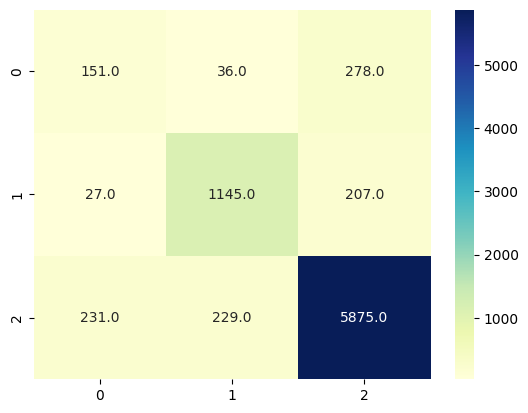

In [36]:
sns.heatmap(cm, annot = True, fmt=".1f", cmap="YlGnBu")
plt.show()

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

0.8767575498227167

In [38]:
sample = "Lets unite and kill all the people who are protesting against the government"
sample = clean_data(sample)

In [39]:
sample

'let unit kill peopl protest govern'

In [40]:
data1 = cv.transform([sample]).toarray()

In [41]:
data1

array([[0, 0, 0, ..., 0, 0, 0]], shape=(1, 25684))

In [42]:
dt.predict(data1)

array(['Hate Speech'], dtype=object)